In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
# Load all sheets
Reviews=pd.read_excel(r'C:\Users\arjun\OneDrive\Documents\scorpio_cafe_audit.xlsx', sheet_name='Reviews')
Popular=pd.read_excel(r'C:\Users\arjun\OneDrive\Documents\scorpio_cafe_audit.xlsx', sheet_name='Popular_Items')
Competitors=pd.read_excel(r'C:\Users\arjun\OneDrive\Documents\scorpio_cafe_audit.xlsx', sheet_name='Competitors')
Complaints=pd.read_excel(r'C:\Users\arjun\OneDrive\Documents\scorpio_cafe_audit.xlsx', sheet_name='Complaints')
print("Data loaded successfully!")


Data loaded successfully!


In [7]:
# Check reviews data
print(Reviews.shape)
print(Reviews.columns)
print(Reviews.head())
print(Reviews.dtypes)

(30, 9)
Index(['review_id', 'reviewer_name', 'rating', 'review_text', 'date',
       'sentiment', 'category', 'item_mentioned', 'complaint'],
      dtype='object')
   review_id reviewer_name  rating  \
0          1     Customer1       3   
1          2     Customer2       1   
2          3     Customer3       1   
3          4     Customer4       4   
4          5     Customer5       3   

                                         review_text       date sentiment  \
0  The Sandwich was really nice and also the cold... 2026-06-05     Mixed   
1                Very disappointing chicken curry... 2026-06-02  Negative   
2                      Taking two hours to deliver.. 2026-04-06  Negative   
3                Chilli garlic noodles were awesome! 2026-04-11  Positive   
4                  Food is good but service too slow 2026-03-06     Mixed   

         category         item_mentioned  \
0        Ambience  Sandwich, Cold Coffee   
1  Food + Service          Chicken Curry   
2        Del

In [9]:
#check missing values
print(Reviews.isnull().sum())

review_id          0
reviewer_name      0
rating             0
review_text        0
date               0
sentiment          0
category           0
item_mentioned     0
complaint         10
dtype: int64


In [10]:
# Sentiment breakdown
print(Reviews['sentiment'].value_counts())

sentiment
Positive    14
Negative     7
Mixed        5
Neutral      4
Name: count, dtype: int64


In [12]:
# Average rating
print(f"Average Rating: {Reviews['rating'].mean():.2f}")

Average Rating: 3.30


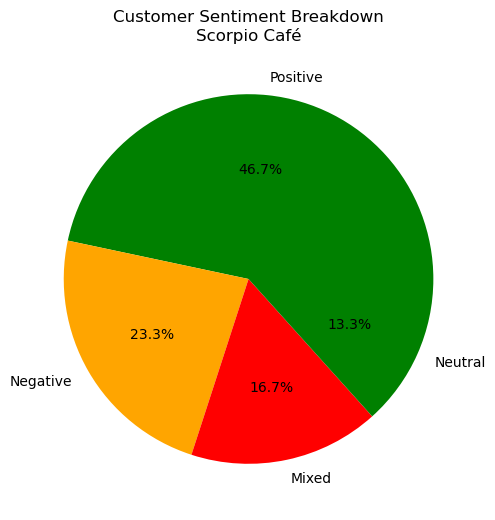

In [14]:
# Sentiment breakdown pie chart
sentiment_counts = Reviews['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts, 
        labels=sentiment_counts.index, 
        autopct='%1.1f%%',
        colors=['green', 'orange', 'red'])
plt.title('Customer Sentiment Breakdown\nScorpio Café')
plt.show()

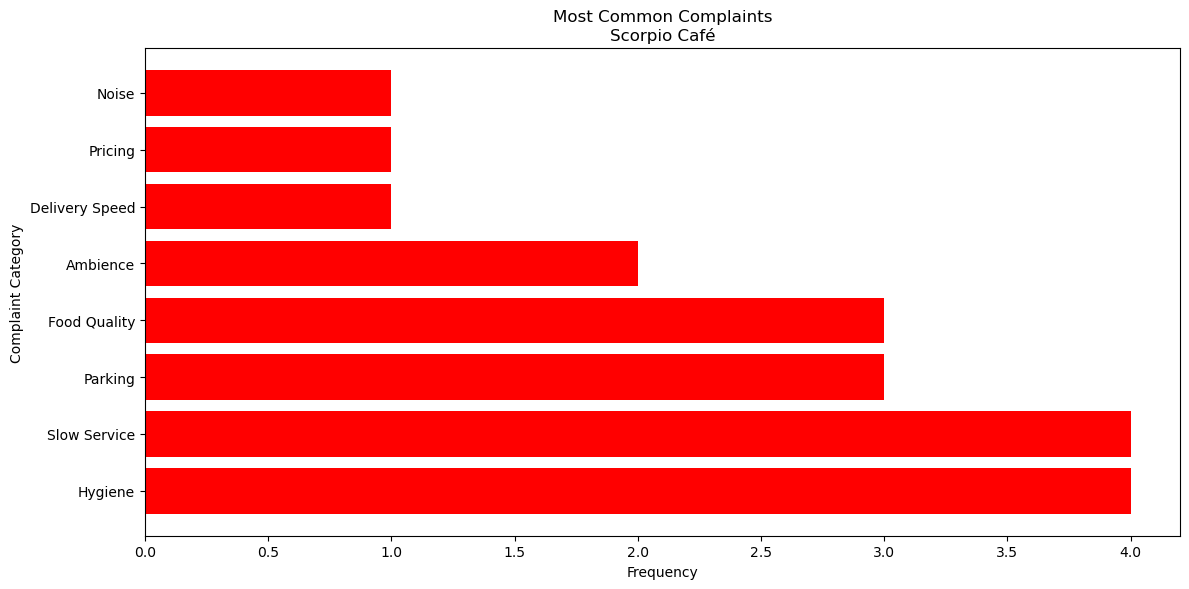

In [17]:
# Complaints bar chart
plt.figure(figsize=(12, 6))
plt.barh(Complaints['Category'], Complaints['Frequency'], color='red')
plt.title('Most Common Complaints\nScorpio Café')
plt.xlabel('Frequency')
plt.ylabel('Complaint Category')
plt.tight_layout()
plt.show()

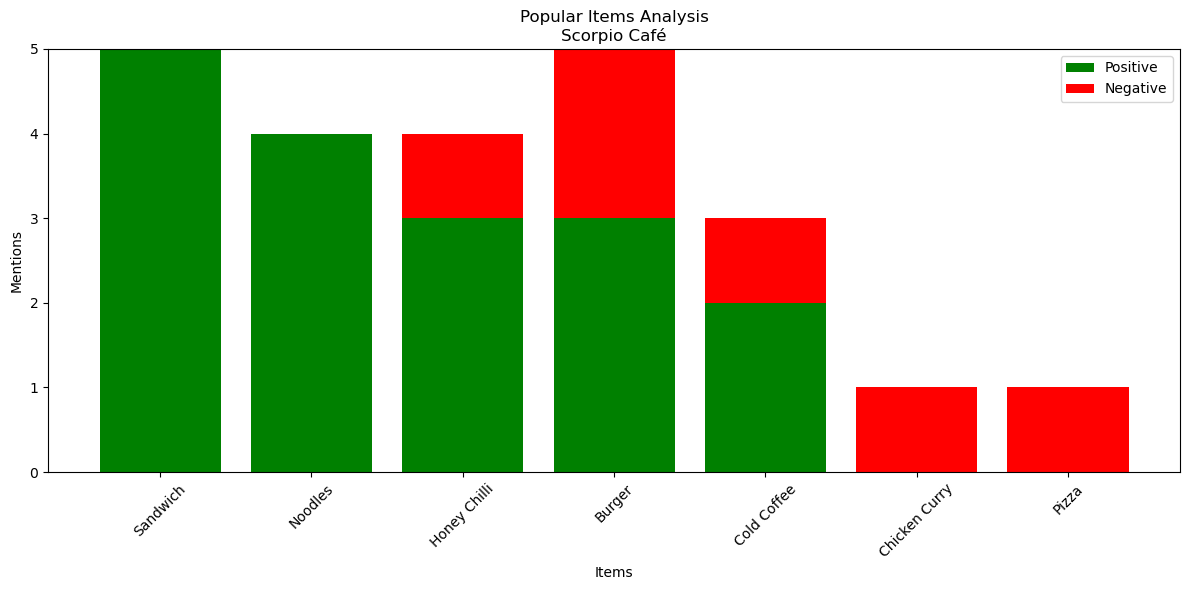

In [18]:
# Popular items chart
plt.figure(figsize=(12, 6))
x = range(len(Popular['item_name']))
plt.bar(x, Popular['positive_mentions'], color='green', label='Positive')
plt.bar(x, Popular['negative_mentions'], color='red', label='Negative', bottom=Popular['positive_mentions'])
plt.xticks(x, Popular['item_name'], rotation=45)
plt.title('Popular Items Analysis\nScorpio Café')
plt.xlabel('Items')
plt.ylabel('Mentions')
plt.legend()
plt.tight_layout()
plt.show()

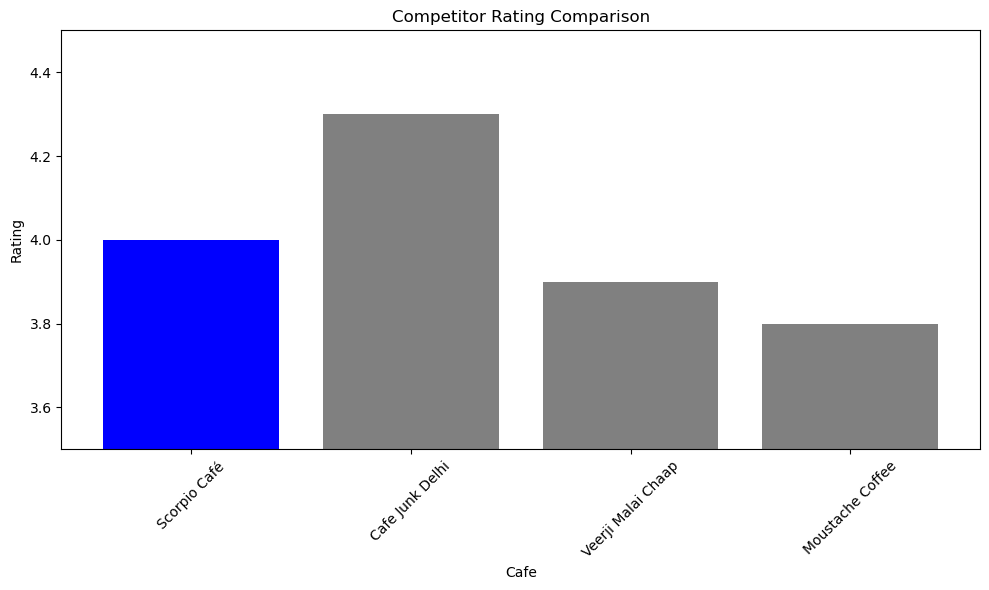

In [20]:
# Add Scorpio to competitors for comparison
all_cafes = pd.DataFrame({
    'name': ['Scorpio Café', 'Cafe Junk Delhi', 'Veerji Malai Chaap', 'Moustache Coffee'],
    'rating': [4.0, 4.3, 3.9, 3.8]})
plt.figure(figsize=(10, 6))
colors = ['blue', 'grey', 'grey', 'grey']
plt.bar(all_cafes['name'], all_cafes['rating'], color=colors)
plt.title('Competitor Rating Comparison')
plt.xlabel('Cafe')
plt.ylabel('Rating')
plt.ylim(3.5, 4.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

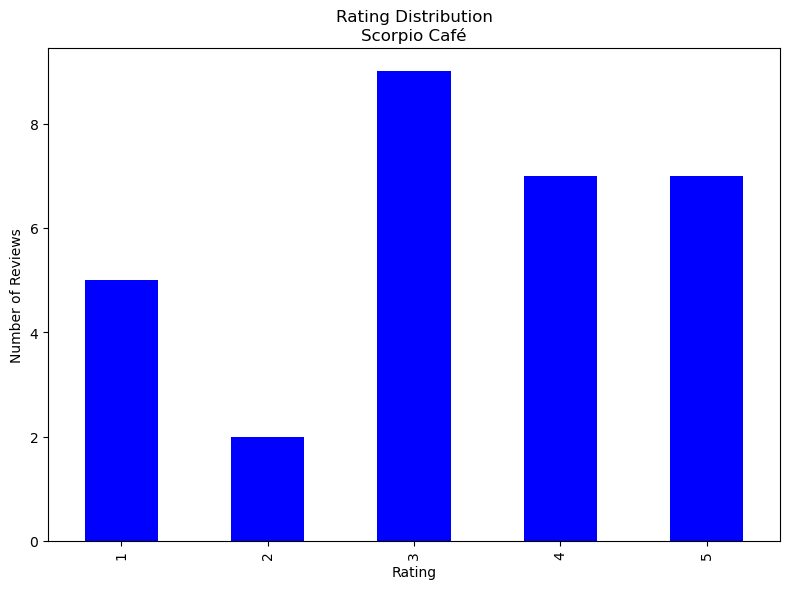

In [21]:
# Rating distribution
plt.figure(figsize=(8, 6))
Reviews['rating'].value_counts().sort_index().plot(kind='bar', color='blue')
plt.title('Rating Distribution\nScorpio Café')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()